# Обучение с учителем
## Регресия как метод прогнозирования
В данном примере загружается датасет, анализируются значения в нём, вносятся необходимые правки и применяется регрессия для прогнозирования

### Сначала как всегда подключаем библиотеки

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

Помимо тех, которые подключали в прошлый раз нужны будут классы для работы с регрессией

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


ModuleNotFoundError: No module named 'sklearn'

### Теперь загрузим датасет и посмотрим его
Будет использован всё тот же датасет с характеристиками опоссумов

In [ ]:
df = pd.read_csv('possum.csv')

In [ ]:
print(df.shape)
print(df.head())

Проверим что в столбцах с числами нет аномальных начений (вроде 0 или отрицательны)

In [5]:
print(df.describe())

             case        site         age     hdlngth      skullw    totlngth  \
count  104.000000  104.000000  102.000000  104.000000  104.000000  104.000000   
mean    52.500000    3.625000    3.833333   92.602885   56.883654   87.088462   
std     30.166206    2.349086    1.909244    3.573349    3.113426    4.310549   
min      1.000000    1.000000    1.000000   82.500000   50.000000   75.000000   
25%     26.750000    1.000000    2.250000   90.675000   54.975000   84.000000   
50%     52.500000    3.000000    3.000000   92.800000   56.350000   88.000000   
75%     78.250000    6.000000    5.000000   94.725000   58.100000   90.000000   
max    104.000000    7.000000    9.000000  103.100000   68.600000   96.500000   

            taill    footlgth    earconch         eye       chest       belly  
count  104.000000  103.000000  104.000000  104.000000  104.000000  104.000000  
mean    37.009615   68.459223   48.130769   15.046154   27.000000   32.586538  
std      1.959518    4.395306 

И отдельно проверим столбцы с текстом

In [6]:
print(df.describe(include=[object]))

          Pop  sex
count     104  104
unique      2    2
top     other    m
freq       58   61


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


Таак! В двух записях нет возраста, и в одной длины ступни, непорядок! Надо их удалить!

In [8]:
df=df[(df['age']>0)&(df['footlgth']>0)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      101 non-null    int64  
 1   site      101 non-null    int64  
 2   Pop       101 non-null    object 
 3   sex       101 non-null    object 
 4   age       101 non-null    float64
 5   hdlngth   101 non-null    float64
 6   skullw    101 non-null    float64
 7   totlngth  101 non-null    float64
 8   taill     101 non-null    float64
 9   footlgth  101 non-null    float64
 10  earconch  101 non-null    float64
 11  eye       101 non-null    float64
 12  chest     101 non-null    float64
 13  belly     101 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.8+ KB


Удалено, отлично!

Следующая проблема - текстовые значения, они нам не нужны, заменим на числа.
Эти значения - m и f в столбце sex и Vic и other в столбце Pop
Заменим первое на 0, а второе на 1, для этого нужно будет объявить словарь подстановки:

In [9]:
sexes = {'m':0, 'f':1}
pops = {'Vic':0, 'other':1}
df=df.replace(sexes)
df=df.replace(pops)

C:\Users\valko\AppData\Local\Temp\ipykernel_23636\942413292.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace(sexes)
C:\Users\valko\AppData\Local\Temp\ipykernel_23636\942413292.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace(pops)


Предупреждение не так важно, и проверим результат:

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      101 non-null    int64  
 1   site      101 non-null    int64  
 2   Pop       101 non-null    int64  
 3   sex       101 non-null    int64  
 4   age       101 non-null    float64
 5   hdlngth   101 non-null    float64
 6   skullw    101 non-null    float64
 7   totlngth  101 non-null    float64
 8   taill     101 non-null    float64
 9   footlgth  101 non-null    float64
 10  earconch  101 non-null    float64
 11  eye       101 non-null    float64
 12  chest     101 non-null    float64
 13  belly     101 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 11.8 KB


Отлично, с этим уже можно работать!

## Теперь подготовка датасета для обучения - отделим признаки от результата
Начнём с регрессии - будем предсказывать длину хвоста. Для этого уберём из числа признаков всё, связанное с длиной.

In [11]:
df_reg_data=df.drop(['taill','totlngth','skullw','footlgth'], axis=1)
df_reg_target=df['taill']


## А теперь линейная регрессия! 
Сначала загрузка метода и обучение модели

In [12]:
linear_regression = LinearRegression()
model_lin = linear_regression.fit(df_reg_data, df_reg_target)

Теперь делаем предсказание

In [13]:
predicted_lin = model_lin.predict(df_reg_data)
print(predicted_lin)

[37.10224853 36.72502379 37.06889774 36.92796278 36.83970141 36.86436993
 36.46607887 37.16378239 36.72123568 36.45074638 36.58713031 36.47067427
 35.52088732 36.06429695 36.01348418 35.3391058  36.39496823 36.12603608
 36.49040678 36.78199134 37.47365554 36.26673874 36.52568071 35.70752398
 35.9242671  36.91116555 34.67382496 35.08659733 35.48158111 35.42882149
 34.9133313  35.97277627 34.40412192 34.86155    36.60898277 35.78428456
 35.50034359 34.56720854 34.2861858  35.18629853 34.38428736 34.8862984
 35.04544569 37.36610285 38.37359585 38.15713308 38.70775452 38.96991778
 37.648474   38.25847336 38.96841707 39.19234245 38.48475483 39.42213133
 38.09246269 38.8769708  37.92576702 37.93055061 37.8547552  38.04856937
 38.97441417 38.76145204 38.32100483 37.36693775 37.33397655 38.42474371
 38.07016817 37.45536979 36.21050414 36.05351333 38.56581035 38.33303437
 38.31534372 37.9423597  36.42579417 36.26799067 36.9152008  37.54643073
 37.37180805 37.20232675 36.5628044  36.94823585 37.

Хм... и как узнать что это за значения? Сравним их с оригиналом! Для этого сформируем миним табличку - в первом столбце будет предсказание, а во втором - реальность. Выведем несколько строк и статистику.

In [14]:
results_table = pd.DataFrame(list(zip(predicted_lin, df_reg_target)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table.head())
print(results_table.describe())

   Предсказано  На самом деле
0    37.102249           36.0
1    36.725024           36.5
2    37.068898           39.0
3    36.927963           38.0
4    36.839701           36.0
       Предсказано  На самом деле
count   101.000000     101.000000
mean     37.049505      37.049505
std       1.257264       1.971681
min      34.286186      32.000000
25%      36.266739      36.000000
50%      37.102249      37.000000
75%      38.048569      38.000000
max      39.422131      43.000000


Ну... Среднее значение даже совпадает! Но всё ещё не наглядно, надо графиком!
На оси 0X будут предсказанные значения, а на оси 0Y - реальные 

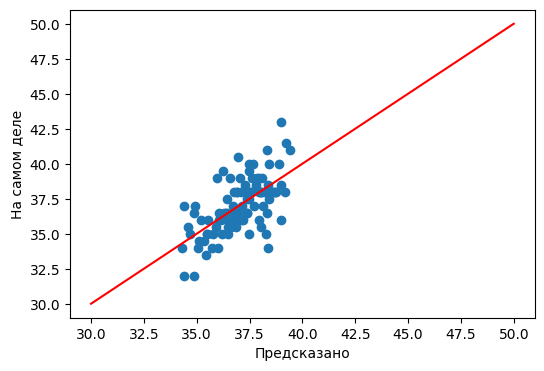

In [15]:
plt.figure(figsize=(6, 4))
plt.scatter(predicted_lin, df_reg_target)
plt.xlabel('Предсказано')
plt.ylabel('На самом деле')
plt.plot([30, 50], [30, 50], color="red")
plt.show()

Не плохо вышло же! 

## Полиномиальная регрессия
А попробуем теперь полиномиальную регрессию 3-й степени.
Сначала создание модели и её обучение.

In [16]:
polynomial_regression = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear', LinearRegression(fit_intercept=False))])
model_pol = polynomial_regression.fit(df_reg_data, df_reg_target)

Теперь предсказание

In [17]:
predicted_pol = model_pol.predict(df_reg_data)
print(predicted_pol)

[36.  36.5 39.  38.  36.  35.5 36.  37.  37.  37.5 39.  35.5 36.  36.
 34.  34.5 36.5 36.  35.  38.  39.5 39.5 36.  34.  35.5 36.  35.  34.5
 35.  33.5 37.  39.  37.  36.5 35.5 35.  35.  35.5 34.  36.  32.  32.
 34.  37.5 34.  37.  38.  36.  40.  38.  43.  38.  38.  41.  39.  40.
 39.  38.  39.  38.  38.5 38.  36.5 36.5 38.  37.5 38.  40.  35.  36.5
 38.  38.  41.  36.  36.5 36.5 38.  38.  36.5 36.  36.  40.5 38.5 41.5
 38.  35.  38.5 38.  37.  38.  35.5 37.5 38.  38.  35.  38.5 36.5 39.
 38.  36.5 40. ]


Хм... что-то не то, а что покажет график и сводная таблица?

In [18]:
results_table = pd.DataFrame(list(zip(predicted_pol, df_reg_target)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table.head())
print(results_table.describe())

   Предсказано  На самом деле
0         36.0           36.0
1         36.5           36.5
2         39.0           39.0
3         38.0           38.0
4         36.0           36.0
       Предсказано  На самом деле
count   101.000000     101.000000
mean     37.049505      37.049505
std       1.971681       1.971681
min      32.000000      32.000000
25%      36.000000      36.000000
50%      37.000000      37.000000
75%      38.000000      38.000000
max      43.000000      43.000000


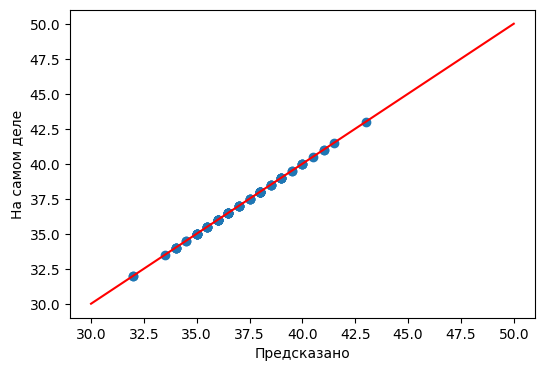

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(predicted_pol, df_reg_target)
plt.xlabel('Предсказано')
plt.ylabel('На самом деле')
plt.plot([30, 50], [30, 50], color="red")
plt.show()

Что-то слишком хорошо предсказывает... Похоже переобучили, попробуем разделить датасет

## Создание обучающей и тестовой выборок
Используем стандартную функцию. Поделим в соотношении 70/30

In [20]:
data_train, data_test, target_train, target_test = train_test_split(
df_reg_data, df_reg_target,
test_size=0.3, random_state=12
)

Повторим полиномиальную регрессию

In [21]:
model_pol = polynomial_regression.fit(data_train, target_train)
predicted_pol = model_pol.predict(data_test)

In [22]:
results_table = pd.DataFrame(list(zip(predicted_pol, target_test)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table.head())
print(results_table.describe())

   Предсказано  На самом деле
0    37.650773           36.0
1    37.333258           32.0
2    41.175522           38.0
3    33.021238           34.0
4    31.864990           36.5
       Предсказано  На самом деле
count    31.000000      31.000000
mean     35.714130      36.951613
std       7.445211       1.872409
min      20.349030      32.000000
25%      32.080099      35.750000
50%      34.802120      37.500000
75%      37.492016      38.000000
max      58.183095      40.000000


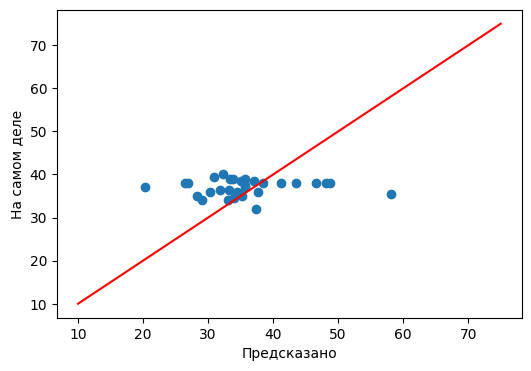

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(predicted_pol, target_test)
plt.xlabel('Предсказано')
plt.ylabel('На самом деле')
plt.plot([10, 75], [10, 75], color="red")
plt.show()

Вот это выглядит реалистичнее, а что с линейной будет?

In [24]:
model_lin = linear_regression.fit(data_train, target_train)
predicted_lin = model_lin.predict(data_test)

In [25]:
results_table = pd.DataFrame(list(zip(predicted_lin, target_test)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table.head())
print(results_table.describe())

   Предсказано  На самом деле
0    36.145770           36.0
1    34.821257           32.0
2    37.602317           38.0
3    36.102492           34.0
4    36.287363           36.5
       Предсказано  На самом деле
count    31.000000      31.000000
mean     36.821047      36.951613
std       1.404020       1.872409
min      33.892565      32.000000
25%      35.782088      35.750000
50%      36.463742      37.500000
75%      38.282856      38.000000
max      38.811327      40.000000


Стало немного хуже, но это на самом деле хорошо - так будет правильнее

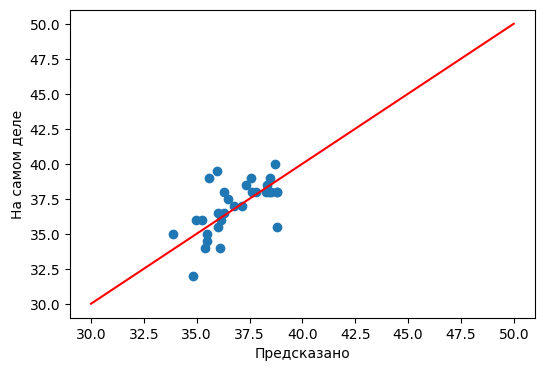

In [26]:
plt.figure(figsize=(6, 4))
plt.scatter(predicted_lin, target_test)
plt.xlabel('Предсказано')
plt.ylabel('На самом деле')
plt.plot([30, 50], [30, 50], color="red")
plt.show()

А линейная то точнее в данном случае!

Можно попробовать убрать часть степеней из полиномиальной модели и посмотреть что выйдет

In [27]:
polynomial_regression_lite = Pipeline([('poly', PolynomialFeatures(degree=3,interaction_only=True)),('linear', LinearRegression(fit_intercept=False))])

In [28]:
model_pol_lite = polynomial_regression_lite.fit(data_train, target_train)
predicted_pol_lite = model_pol_lite.predict(data_test)
results_table = pd.DataFrame(list(zip(predicted_pol_lite, target_test)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table.head())
print(results_table.describe())

   Предсказано  На самом деле
0    32.608138           36.0
1    34.308031           32.0
2    38.247373           38.0
3    33.336515           34.0
4    32.988878           36.5
       Предсказано  На самом деле
count    31.000000      31.000000
mean     36.214032      36.951613
std       6.494941       1.872409
min      19.736446      32.000000
25%      33.162696      35.750000
50%      35.233468      37.500000
75%      38.211321      38.000000
max      54.056355      40.000000


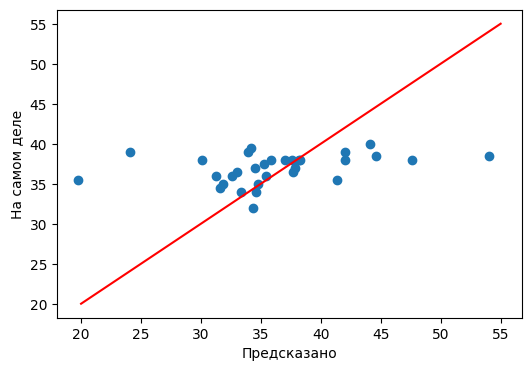

In [29]:
plt.figure(figsize=(6, 4))
plt.scatter(predicted_pol_lite, target_test)
plt.xlabel('Предсказано')
plt.ylabel('На самом деле')
plt.plot([20, 55], [20, 55], color="red")
plt.show()

Всё ещё не особо

## Попробуем Лассо

In [30]:
lin_lasso=Lasso()
model_lin_lasso=lin_lasso.fit(data_train, target_train)
predicted_lin_lasso = model_lin_lasso.predict(data_test)

In [31]:
results_table = pd.DataFrame(list(zip(predicted_lin_lasso, target_test)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table.head())
print(results_table.describe())

   Предсказано  На самом деле
0    36.225843           36.0
1    36.481039           32.0
2    37.801956           38.0
3    36.440230           34.0
4    36.355825           36.5
       Предсказано  На самом деле
count    31.000000      31.000000
mean     36.971785      36.951613
std       0.788489       1.872409
min      35.869957      32.000000
25%      36.315727      35.750000
50%      36.810248      37.500000
75%      37.626149      38.000000
max      38.365015      40.000000


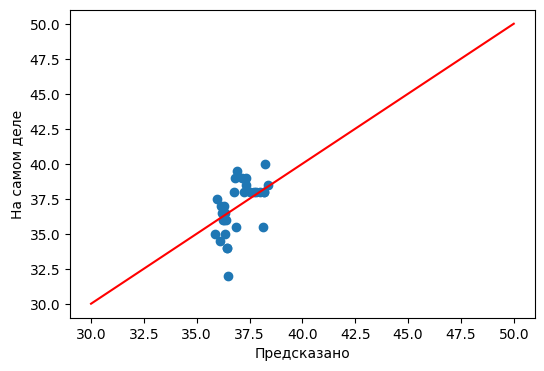

In [32]:
plt.figure(figsize=(6, 4))
plt.scatter(predicted_lin_lasso, target_test)
plt.xlabel('Предсказано')
plt.ylabel('На самом деле')
plt.plot([30, 50], [30, 50], color="red")
plt.show()

А вот это явно помогает!

## Теперь гребень

In [33]:
lin_ridge=Ridge()
model_lin_ridge=lin_ridge.fit(data_train, target_train)
predicted_lin_ridge = model_lin_ridge.predict(data_test)

In [34]:
results_table = pd.DataFrame(list(zip(predicted_lin_ridge, target_test)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table.head())
print(results_table.describe())

   Предсказано  На самом деле
0    35.906173           36.0
1    35.397099           32.0
2    37.598235           38.0
3    36.226498           34.0
4    35.962411           36.5
       Предсказано  На самом деле
count    31.000000      31.000000
mean     36.904804      36.951613
std       1.319834       1.872409
min      34.146257      32.000000
25%      35.884995      35.750000
50%      36.490129      37.500000
75%      38.117723      38.000000
max      39.084518      40.000000


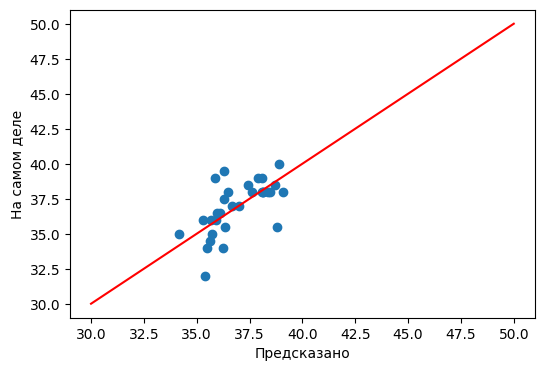

In [35]:
plt.figure(figsize=(6, 4))
plt.scatter(predicted_lin_ridge, target_test)
plt.xlabel('Предсказано')
plt.ylabel('На самом деле')
plt.plot([30, 50], [30, 50], color="red")
plt.show()

## И эластичную сеть

In [36]:
lin_EN=ElasticNet()
model_lin_EN=lin_EN.fit(data_train, target_train)
predicted_lin_EN = model_lin_EN.predict(data_test)

In [37]:
results_table = pd.DataFrame(list(zip(predicted_lin_EN, target_test)))
results_table.columns = ['Предсказано', 'На самом деле']
print(results_table.head())
print(results_table.describe())

   Предсказано  На самом деле
0    35.955437           36.0
1    36.454000           32.0
2    37.663934           38.0
3    36.457976           34.0
4    36.106875           36.5
       Предсказано  На самом деле
count    31.000000      31.000000
mean     36.975490      36.951613
std       0.948958       1.872409
min      35.451297      32.000000
25%      36.135946      35.750000
50%      36.753960      37.500000
75%      37.634558      38.000000
max      38.822034      40.000000


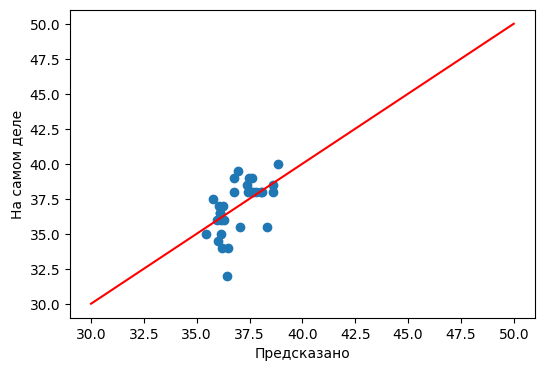

In [38]:
plt.figure(figsize=(6, 4))
plt.scatter(predicted_lin_EN, target_test)
plt.xlabel('Предсказано')
plt.ylabel('На самом деле')
plt.plot([30, 50], [30, 50], color="red")
plt.show()

## Сводная таблица

In [39]:
results_table = pd.DataFrame(list(zip(predicted_lin,predicted_lin_lasso,predicted_lin_ridge,predicted_lin_EN,predicted_pol_lite, target_test)))
results_table.columns = ['Линейная',"Лассо","Гребень","Сеть","Полиномиальная", 'На самом деле']
print(results_table.head())
print(results_table.describe())

    Линейная      Лассо    Гребень       Сеть  Полиномиальная  На самом деле
0  36.145770  36.225843  35.906173  35.955437       32.608138           36.0
1  34.821257  36.481039  35.397099  36.454000       34.308031           32.0
2  37.602317  37.801956  37.598235  37.663934       38.247373           38.0
3  36.102492  36.440230  36.226498  36.457976       33.336515           34.0
4  36.287363  36.355825  35.962411  36.106875       32.988878           36.5
        Линейная      Лассо    Гребень       Сеть  Полиномиальная  \
count  31.000000  31.000000  31.000000  31.000000       31.000000   
mean   36.821047  36.971785  36.904804  36.975490       36.214032   
std     1.404020   0.788489   1.319834   0.948958        6.494941   
min    33.892565  35.869957  34.146257  35.451297       19.736446   
25%    35.782088  36.315727  35.884995  36.135946       33.162696   
50%    36.463742  36.810248  36.490129  36.753960       35.233468   
75%    38.282856  37.626149  38.117723  37.634558      

Лассо выглядит лучше всего, но нет ли другого способа оценить ошибку? Узнаете в следующий раз!